## Running basic analyses on python 
Sep 3 - Lecture 01 notes

### Displaying data from a dataset

Set up py packages:

In [9]:
import statistics as stats
import matplotlib.pyplot as plt
import pandas as pd

path = '/Users/Naomi/Documents/GitHub/datasci185fall2026/Lecture_01/data/features.csv'
carfeatures = pd.read_csv(path) # open dataset 

Display data for all columns.

In [10]:
display(carfeatures)

,mpg,cylinders,displacement,horsepower,weight,acceleration,vehicle id
0,18.0,8,307,130,3504,12.0,C-1689780
1,15.0,8,350,165,3693,11.5,B-1689791
2,18.0,8,318,150,3436,11.0,P-1689802
3,16.0,8,304,150,3433,12.0,A-1689813
4,17.0,8,302,140,3449,10.5,F-1689824
...,...,...,...,...,...,...,...
393,27.0,4,140,86,2790,15.6,F-1694103
394,44.0,4,97,52,2130,24.6,V-1694114
395,32.0,4,135,84,2295,11.6,D-1694125
396,28.0,4,120,79,2625,18.6,F-1694136


Output data for a single column, 'cylinders'. Square brackets, [...] subsets information from data.

In [11]:
display(carfeatures['cylinders'])

0      8
1      8
2      8
3      8
4      8
      ..
393    4
394    4
395    4
396    4
397    4
Name: cylinders, Length: 398, dtype: int64

To compute a frequency table, use crosstab.
Crosstab counts rows as categories
- "index": category; data to pull frequencies from
- "columns": custom title.

In [12]:
table = pd.crosstab(index = carfeatures['cylinders'],columns = "count")
display(table) 

col_0,count
cylinders,
3,4
4,204
5,3
6,84
8,103


We can also cross tabulate between two columns, grouping initial frequencies (cylinders) by a second categegory (mpg).

In [13]:
table_2 = pd.crosstab(index = carfeatures['cylinders'],columns = carfeatures['mpg'])
display(table_2)

mpg,9.0,10.0,11.0,12.0,13.0,14.0,14.5,15.0,15.5,16.0,...,39.4,40.8,40.9,41.5,43.1,43.4,44.0,44.3,44.6,46.6
cylinders,,,,,,,,,,,,,,,,,,,,,
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,1,1,1,1,1,1,1,1,1,1
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,4,0,5,...,0,0,0,0,0,0,0,0,0,0
8,1,2,4,6,20,19,1,12,5,8,...,0,0,0,0,0,0,0,0,0,0


### Computing basic stats

"describe" computes the count, mean, std, min, 25% quantile, 50%, 75%, max

In [14]:
carfeatures.describe()
# carfeatures.describe(percentiles=[.33, .66]) to describe the 33, 66 percentile

,mpg,cylinders,displacement,weight,acceleration
count,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.427136,2970.424623,15.568090
std,7.815984,1.701004,104.268683,846.841774,2.757689
min,9.000000,3.000000,68.000000,1613.000000,8.000000
25%,17.500000,4.000000,104.250000,2223.750000,13.825000
50%,23.000000,4.000000,148.500000,2803.500000,15.500000
75%,29.000000,8.000000,262.000000,3608.000000,17.175000
max,46.600000,8.000000,455.000000,5140.000000,24.800000


It's often better to round outputs.
Round(value, digits)

In [15]:
round(carfeatures.describe(), 2)

,mpg,cylinders,displacement,weight,acceleration
count,398.00,398.00,398.00,398.00,398.00
mean,23.51,5.45,193.43,2970.42,15.57
std,7.82,1.70,104.27,846.84,2.76
min,9.00,3.00,68.00,1613.00,8.00
25%,17.50,4.00,104.25,2223.75,13.82
50%,23.00,4.00,148.50,2803.50,15.50
75%,29.00,8.00,262.00,3608.00,17.18
max,46.60,8.00,455.00,5140.00,24.80


### Scatter plots - plt.scatter

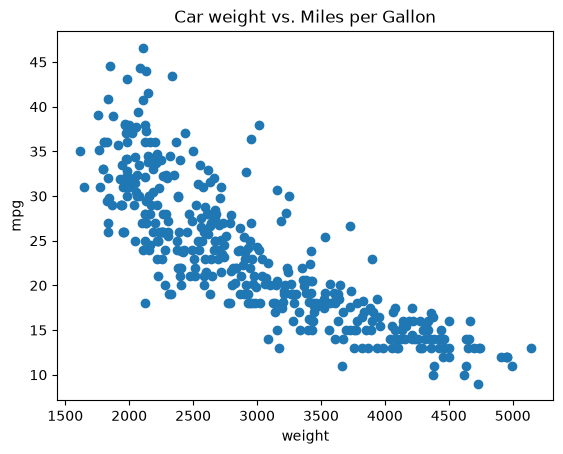

In [16]:
plt.scatter(x = carfeatures['weight'], y = carfeatures['mpg'])

# Add title & labels for axes
plt.title("Car weight vs. Miles per Gallon")
plt.xlabel('weight')
plt.ylabel('mpg')

plt.show()

Simply plotting both with plot data on the same plot (overlayed). Scale and information is not preserved.



## Polars

Sep 4 - Lab02 Notes

In [17]:
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

### Comparing Pandas vs. Polar
In Pandas, we used pd.read_csv() to load a file.

Polars has its own function for reading csv files. Note the difference:

In [18]:
path = "Lab_02/data/student_data.csv"

pandas_df = pd.read_csv(path)
pandas_df.head()

,name,major,year,study_hours,exam_score,attendance
0,Ava,CS,1,5,82,90
1,Ben,Biology,2,3,74,80
2,Cam,CS,3,8,94,98
3,Dani,Math,2,6,88,92
4,Eli,Biology,4,2,68,75


In [19]:
polars_df = pl.read_csv(path)
polars_df.head()

name,major,year,study_hours,exam_score,attendance
str,str,i64,i64,i64,i64
"""Ava""","""CS""",1,5,82,90
"""Ben""","""Biology""",2,3,74,80
"""Cam""","""CS""",3,8,94,98
"""Dani""","""Math""",2,6,88,92
"""Eli""","""Biology""",4,2,68,75


In [22]:
polars_df['year'] # Similarly, we can access a singular variable/column.

polars_df.describe()
# polars_df.describe(percent=[0.33, 0.66])

statistic,name,major,year,study_hours,exam_score,attendance
str,str,str,f64,f64,f64,f64
"""count""","""10""","""10""",10.0,10.0,10.0,10.0
"""null_count""","""0""","""0""",0.0,0.0,0.0,0.0
"""mean""",null,null,2.5,5.5,84.8,89.5
"""std""",null,null,1.080123,2.173067,9.126275,7.763876
"""min""","""Ava""","""Biology""",1.0,2.0,68.0,75.0
"""25%""",null,null,2.0,4.0,79.0,84.0
"""50%""",null,null,3.0,6.0,88.0,92.0
"""75%""",null,null,3.0,7.0,91.0,95.0
"""max""","""Jada""","""Math""",4.0,9.0,97.0,99.0


Describe in Pandas and Polar are also different-- outputting dif. information & format

### Seaborn vs. Matplotlib

Both create visualizations, but:
- Matplotlib gives detailed, low-level control
- Seaborn is built on Matplotlib and provides a higher-level interface

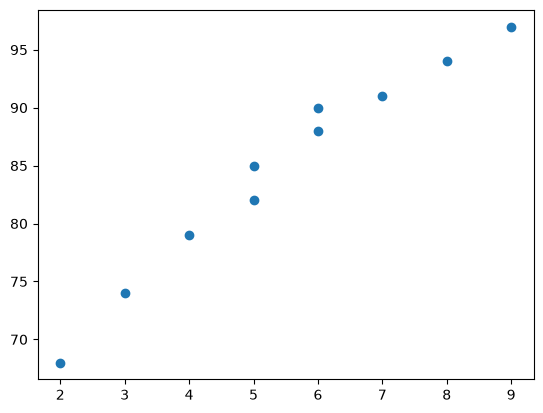

In [24]:
# In Matplotlib
plt.scatter(x = pandas_df["study_hours"], y = pandas_df["exam_score"])
plt.show()

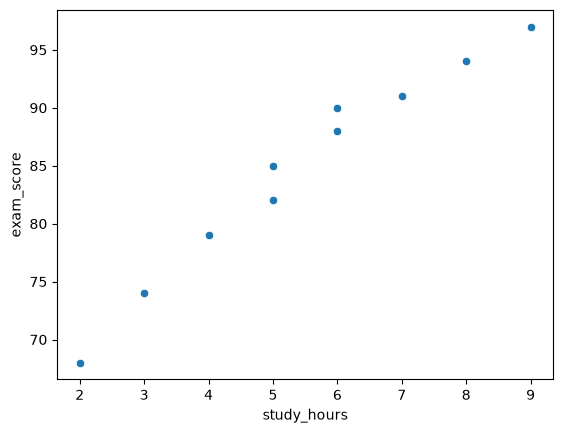

In [23]:
# In Seaborn
sns.scatterplot(x = pandas_df["study_hours"], y = pandas_df["exam_score"])
plt.show() 

Seaborn automatically creates axes labels. We can modify these labels the same way as we would in Matplotlib:
- sns.xlabel("label")
- sns.ylabel("label")
- sns.title("title")

In general, Seaborn can generate more appealing charts.
- sns.set_theme(style="whitegrid")
- sns.scatterplot(..., color="steelblue", alpha=0.5)

** Alpha sets opacity